In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

Variants v.s. Hospitalization

In [ ]:
hosp = pd.read_csv("/Users/boyapeng/Desktop/Dissertation/Aim2/Data/COVID_hosp_21-26.csv",header=0)
variant = pd.read_csv("/Users/boyapeng/Desktop/Dissertation/Aim2/Data/SARS-CoV-2_Variant_Proportions_20260126.csv",header=0)

In [56]:
duplicates = variant1[variant1.duplicated(subset=['Date', 'variant'], keep=False)]
duplicates = duplicates.sort_values(['Date', 'variant'])
print(duplicates)

       usa_or_hhsregion          week_ending    variant     share  share_hi  \
49974               USA  2021-07-10 00:00:00  B.1.1.529  0.000048  0.000194   
30903               USA  2021-07-10 00:00:00  B.1.1.529  0.000048  0.000194   
46841               USA  2021-07-10 00:00:00  B.1.1.529  0.000048  0.000194   
27776               USA  2021-07-10 00:00:00  B.1.1.529  0.000048  0.000194   
46842               USA  2021-07-10 00:00:00  B.1.617.2  0.668415  0.672938   
...                 ...                  ...        ...       ...       ...   
147926              USA  2025-11-22 00:00:00        XFV  0.011617  0.020805   
233491              USA  2025-11-22 00:00:00        XFY  0.009653  0.023723   
147927              USA  2025-11-22 00:00:00        XFY  0.005808  0.013271   
147928              USA  2025-11-22 00:00:00        XFZ  0.020329  0.031458   
233492              USA  2025-11-22 00:00:00        XFZ  0.015444  0.031436   

        share_lo modeltype time_interval       Date

In [3]:
variant1 = variant[
    (variant['usa_or_hhsregion'] == 'USA') & 
    (variant['modeltype'] == 'empiric') &
    (variant['time_interval'] == '4_week')
].copy()
variant1 = variant1.drop(columns=['published_date','nchs_or_count_flag'], errors='ignore')
columns_to_check = ['week_ending', 'variant', 'share']
variant1 = variant1.drop_duplicates(subset=columns_to_check).copy()

hosp1 = hosp[ (hosp['State'] == 'COVID-NET') & 
    (hosp['AgeCategory_Legend'] == 'All') & 
    (hosp['Sex_Label'] == 'All') & 
    (hosp['Race_Label'] == 'All') & 
    (hosp['Type'] == 'Crude Rate')
].copy()

# 2. Preprocess dates and sort
hosp1['Date'] = pd.to_datetime(hosp1['_WeekendDate'], errors='coerce')
variant1['Date'] = pd.to_datetime(variant1['week_ending'].str.split().str[0], errors='raise')

variant1 = variant1.dropna(subset=['Date']).sort_values('Date')
hosp1 = hosp1.dropna(subset=['Date']).sort_values('Date')

# 3. Synchronize date ranges 
# (Filters hospitalization data to match the range available in the variant data)
start_date = variant1['Date'].min()
end_date = variant1['Date'].max()
hosp_filtered = hosp1[(hosp1['Date'] >= start_date) & 
                     (hosp1['Date'] <= end_date)]

# 4. Prepare Variant data for stacked bar plotting (Pivot)
# This converts the "long" format table into a "wide" format for stacking
variant_pivot = variant1.pivot_table(
    index='Date', 
    columns='variant', 
    values='share', 
    aggfunc='mean'  # If they are identical, mean remains the same value
).fillna(0)

# If shares are in [0,1], convert to percent; if already [0,100], keep as-is
share_max = float(variant_pivot.to_numpy().max()) if variant_pivot.size else 0.0
if share_max <= 1.5:
    variant_pivot *= 100.0

# Sort columns by their average share so the most dominant variants are prominent
variant_pivot = variant_pivot[variant_pivot.mean().sort_values(ascending=False).index]


In [4]:
variant1

,usa_or_hhsregion,week_ending,variant,share,share_hi,share_lo,modeltype,time_interval,Date
27768,USA,2021-05-15 00:00:00,B.1.1.529,0.000068,0.000440,0.000004,empiric,4_week,2021-05-15
27769,USA,2021-05-15 00:00:00,B.1.617.2,0.026569,0.029325,0.024062,empiric,4_week,2021-05-15
27770,USA,2021-05-15 00:00:00,BA.1.1,0.000136,0.000547,0.000023,empiric,4_week,2021-05-15
27771,USA,2021-05-15 00:00:00,Other,0.973228,0.975744,0.970462,empiric,4_week,2021-05-15
27772,USA,2021-06-12 00:00:00,B.1.1.529,0.000175,0.000434,0.000064,empiric,4_week,2021-06-12
...,...,...,...,...,...,...,...,...,...
147933,USA,2025-12-20 00:00:00,LP.8.1,0.001279,0.008263,0.000067,empiric,4_week,2025-12-20
147932,USA,2025-12-20 00:00:00,LF.7.9,0.001279,0.008263,0.000067,empiric,4_week,2025-12-20
147931,USA,2025-12-20 00:00:00,LF.7,0.001279,0.008263,0.000067,empiric,4_week,2025-12-20
147929,USA,2025-12-20 00:00:00,B.1.1.529,0.001279,0.008263,0.000067,empiric,4_week,2025-12-20


In [51]:
#use time_interval='biweekly' from 1/30/2021, 'weekly' from 3/6/2021, biweekly from 4/15/2023, 4_week from 6/7/2025

# ensure datetime
variant['Date'] = pd.to_datetime(variant['week_ending'].str.split().str[0], errors='raise')
variant["Date"] = pd.to_datetime(variant["Date"])

variant2 = variant[
    (variant["usa_or_hhsregion"] == "USA") &
    (variant["nchs_or_count_flag"] == 0.0) &
    (
        (
            (variant["Date"] <  pd.Timestamp("2021-03-06")) &
            (variant["time_interval"] == "biweekly")
        )
        |
        (
            (variant["Date"] >= pd.Timestamp("2021-03-06")) &
            (variant["Date"] <  pd.Timestamp("2023-04-15")) &
            (variant["time_interval"] == "weekly")
        )
        |
        (
            (variant["Date"] >= pd.Timestamp("2023-04-15")) &
            (variant["Date"] <  pd.Timestamp("2025-06-07")) &
            (variant["time_interval"] == "biweekly")
        )
        |
        (
            (variant["Date"] >= pd.Timestamp("2025-06-07")) &
            (variant["time_interval"] == "4_week")
        )
    )
].copy()

variant2 = variant2.drop(columns='published_date', errors='ignore')
columns_to_check = ['week_ending', 'variant', 'share']
variant2 = variant2.drop_duplicates(subset=columns_to_check).copy()
variant2 = variant2.dropna(subset=['Date']).sort_values('Date')

In [27]:
variant2

,usa_or_hhsregion,week_ending,variant,share,share_hi,share_lo,nchs_or_count_flag,modeltype,time_interval,Date
2910354,USA,2021-01-30 00:00:00,B.1.1.7,0.046679,0.115425,0.018042,0.0,weighted,weekly,2021-01-30
1685704,USA,2021-01-30 00:00:00,B.1.2,0.422859,0.491968,0.356643,0.0,weighted,biweekly,2021-01-30
1685705,USA,2021-01-30 00:00:00,B.1.427,0.033127,0.065798,0.016394,0.0,weighted,biweekly,2021-01-30
1685706,USA,2021-01-30 00:00:00,B.1.429,0.083408,0.196670,0.032717,0.0,weighted,biweekly,2021-01-30
1685707,USA,2021-01-30 00:00:00,B.1.526,0.008542,0.019982,0.003628,0.0,weighted,biweekly,2021-01-30
...,...,...,...,...,...,...,...,...,...,...
147922,USA,2025-11-22 00:00:00,XFG,0.679574,0.707791,0.650004,0.0,empiric,4_week,2025-11-22
147918,USA,2025-11-22 00:00:00,NW.1,0.015489,0.025605,0.009187,0.0,empiric,4_week,2025-11-22
233489,USA,2025-11-22 00:00:00,XFG.6,0.021236,0.038839,0.011206,0.0,empiric,4_week,2025-11-22
233482,USA,2025-11-22 00:00:00,NB.1.8.1,0.092664,0.121793,0.069761,0.0,empiric,4_week,2025-11-22


In [59]:
variant[(variant['Date'] == '2025-06-07') & (variant['usa_or_hhsregion'] == 'USA') & (variant['variant'] == 'LP.8.1')]

,usa_or_hhsregion,week_ending,variant,share,share_hi,share_lo,nchs_or_count_flag,modeltype,time_interval,published_date,Date
18526,USA,2025-06-07 00:00:00,LP.8.1,0.473535,0.545685,0.402436,NaN,smoothed,biweekly,2025-06-20 00:00:00,2025-06-07
61005,USA,2025-06-07 00:00:00,LP.8.1,0.384772,0.571171,0.225059,NaN,smoothed,biweekly,2025-06-06 00:00:00,2025-06-07
109573,USA,2025-06-07 00:00:00,LP.8.1,0.523112,0.546559,0.499563,0.0,empiric,4_week,2026-01-16 00:00:00,2025-06-07
143601,USA,2025-06-07 00:00:00,LP.8.1,0.526934,0.552888,0.500835,0.0,empiric,4_week,2025-09-26 00:00:00,2025-06-07
154823,USA,2025-06-07 00:00:00,LP.8.1,0.527197,0.551328,0.502939,0.0,empiric,4_week,2025-11-21 00:00:00,2025-06-07
205095,USA,2025-06-07 00:00:00,LP.8.1,0.527164,0.551281,0.502921,0.0,empiric,4_week,2025-12-19 00:00:00,2025-06-07
329799,USA,2025-06-07 00:00:00,LP.8.1,0.429874,0.456075,0.404054,0.0,empiric,4_week,2025-08-29 00:00:00,2025-06-07


In [47]:
# Remove "Other"
variant2_no_other = variant2[variant2["variant"] != "Other"].copy()

# For each Date, get index of max share
idx = variant2_no_other.groupby("Date")["share"].idxmax()

# Select dominant variants
dominant_wave = variant2_no_other.loc[idx].sort_values("Date").reset_index(drop=True)

dominant_wave.to_csv("dominant_wave.csv", index=False)

In [47]:
print(f"Variant range: {variant['week_ending'].min()} to {variant['week_ending'].max()}")

Variant range: 2021-01-02 00:00:00 to 2026-01-17 00:00:00


In [58]:
print(f"Variant range: {variant1['Date'].min()} to {variant1['Date'].max()}")
print(f"Hosp range: {hosp1['Date'].min()} to {hosp1['Date'].max()}")
print(f"Hosp range: {hosp_filtered['Date'].min()} to {hosp_filtered['Date'].max()}")

Variant range: 2021-05-15 00:00:00 to 2025-12-20 00:00:00
Hosp range: 2020-03-07 00:00:00 to 2026-01-17 00:00:00
Hosp range: 2021-05-15 00:00:00 to 2025-12-20 00:00:00


/var/folders/vy/m4l1bmcs7xd4nmd991yq7qkr0000gn/T/ipykernel_35302/430962176.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_plot_clean['Other'] = 100 - variant_plot_clean.sum(axis=1)
/var/folders/vy/m4l1bmcs7xd4nmd991yq7qkr0000gn/T/ipykernel_35302/430962176.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20c', len(variant_plot_clean.columns))


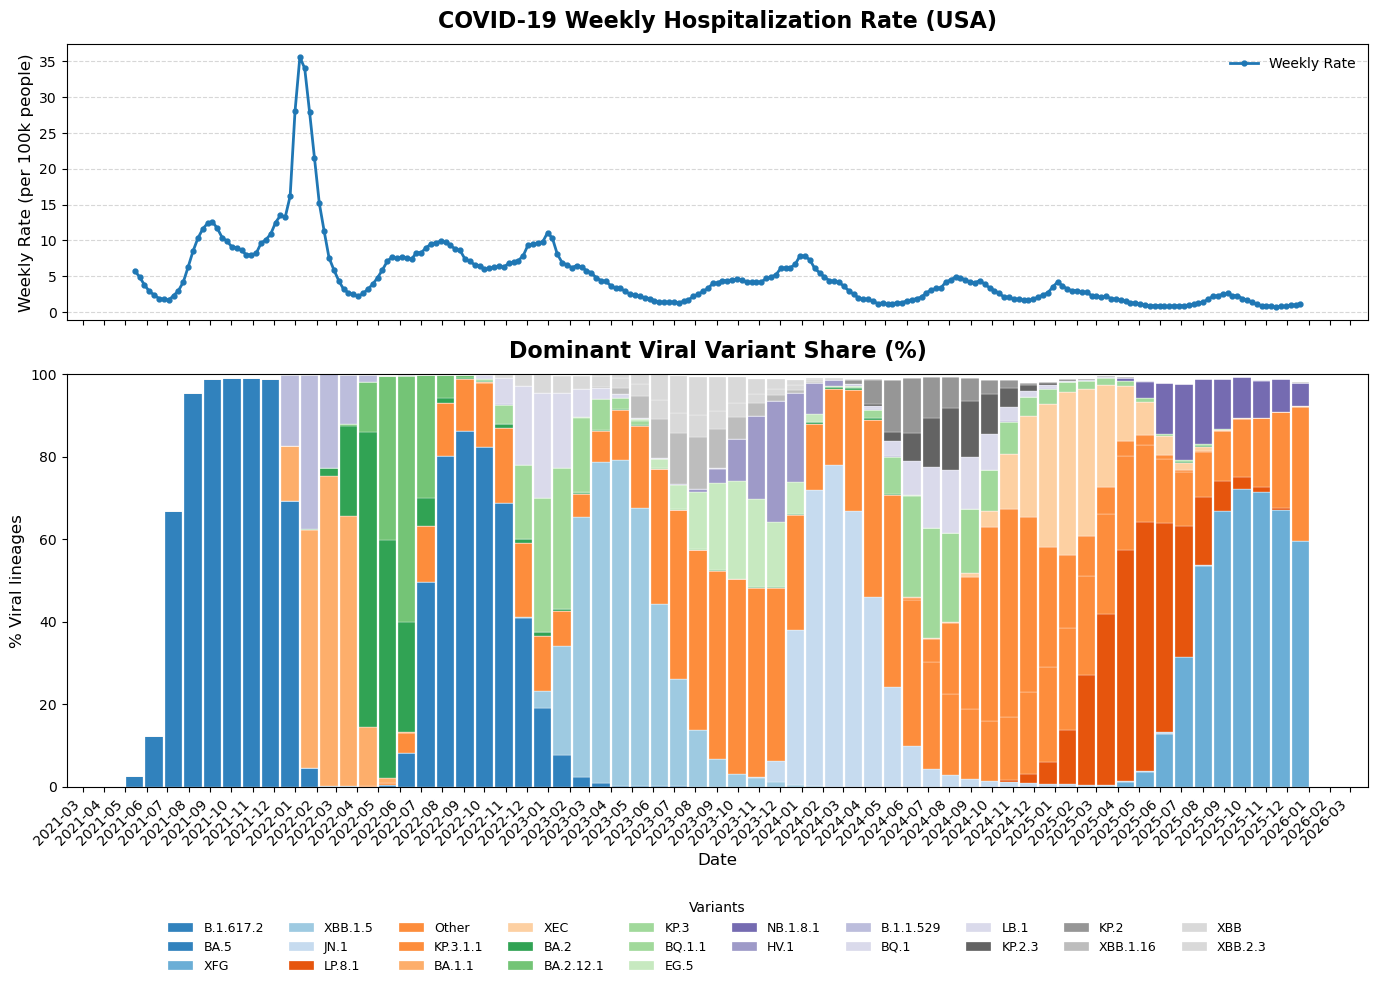

In [77]:
# 5. Create the Visualization (sharex works if BOTH axes use datetime x)
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1.5]}
)

# --- Top: weekly hospitalization (line) ---
ax1.plot(
    hosp_filtered['Date'],
    hosp_filtered['WeeklyRate'],
    marker='o',
    markersize=3.5,
    linewidth=2,
    label='Weekly Rate'
)
ax1.set_title('COVID-19 Weekly Hospitalization Rate (USA)', fontweight='bold', fontsize=16, pad=12)
ax1.set_ylabel('Weekly Rate (per 100k people)', fontsize=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax1.legend(frameon=False)

# --- Bottom: monthly variant shares (stacked bars) on DATETIME x-axis ---
# Ensure shares are in percent for stacked bars
variant_plot = variant_pivot.copy()
if variant_plot.to_numpy().max() <= 1.5:
    variant_plot *= 100.0

# Keep variants with mean share >= 2%
threshold = 0.8

major = variant_plot.columns[variant_plot.mean() >= threshold]
variant_plot_clean = variant_plot[major]

variant_plot_clean['Other'] = 100 - variant_plot_clean.sum(axis=1)

# Choose bar width ~ 25 days so monthly bars look nice on a weekly axis
bar_width_days = 25

bottom = None
cmap = plt.cm.get_cmap('tab20c', len(variant_plot_clean.columns))

for i, col in enumerate(variant_plot_clean.columns):
    y = variant_plot_clean[col].values
    if bottom is None:
        ax2.bar(
            variant_plot_clean.index, y,
            width=bar_width_days,
            align='center',
            label=str(col),
            color=cmap(i),
            edgecolor='white',
            linewidth=0.2
        )
        bottom = y.copy()
    else:
        ax2.bar(
            variant_plot_clean.index, y,
            width=bar_width_days,
            align='center',
            bottom=bottom,
            label=str(col),
            color=cmap(i),
            edgecolor='white',
            linewidth=0.2
        )
        bottom = bottom + y

ax2.set_title('Dominant Viral Variant Share (%)', fontweight='bold', fontsize=16, pad=12)
ax2.set_ylabel('% Viral lineages', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylim(0, 100)

# X-axis: weekly ticks are too dense; use monthly ticks for readability
import matplotlib.dates as mdates
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Legend outside
ax2.legend(
    title='Variants',
    #bbox_to_anchor=(1.02, 1),
    #loc='upper left',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=10,
    fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig('variant_hosp_correlation.png', dpi=300, bbox_inches='tight')
plt.show()


dominant variants (50%) over time (start-peak-end)

      variant start_date  peak_date  peak_share_%   end_date  duration_days
0       Other 2021-05-15 2021-05-15     97.322762 2025-12-20           1680
1   B.1.617.2 2021-05-15 2021-10-30     99.163841 2023-09-02            840
2      BA.1.1 2021-05-15 2022-02-19     75.003941 2024-08-03           1176
3        BA.2 2021-10-02 2022-04-16     71.547492 2025-08-02           1400
4   BA.2.12.1 2021-10-02 2022-06-11     59.732178 2024-08-31           1064
5        BA.5 2021-10-02 2022-09-03     86.272152 2024-03-16            896
6     XBB.1.5 2021-10-30 2023-04-15     78.891803 2025-04-12           1260
7        JN.1 2021-11-27 2024-02-17     77.902882 2025-08-30           1372
8    KP.3.1.1 2023-12-23 2024-10-26     50.548648 2025-12-20            728
9      LP.8.1 2024-01-20 2025-05-10     60.324156 2025-12-20            700
10        XFG 2025-02-15 2025-09-27     72.269173 2025-12-20            308


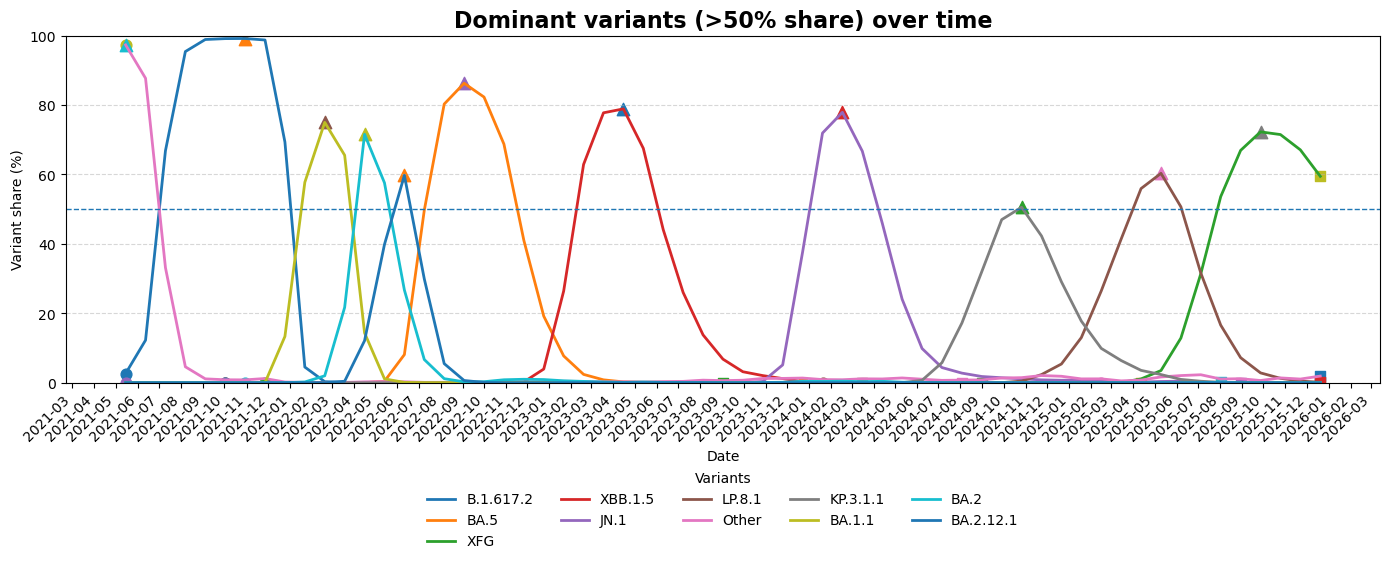

In [79]:
# INPUT: variant1 (already filtered), with columns: Date, variant, share

# 2) Identify dominant variants (ever exceed 50% at any time)
dominant_cols = variant_pivot.columns[(variant_pivot.max(axis=0) > 50.0)]
dom = variant_pivot[dominant_cols].copy()

# If none exceed 50%, you can still see the top variant over time (optional fallback)
# if dom.shape[1] == 0:
#     top_col = variant_pivot.mean(axis=0).sort_values(ascending=False).index[0]
#     dom = variant_pivot[[top_col]].copy()

# 3) Compute start / peak / end for each dominant variant
rows = []
for v in dom.columns:
    s = dom[v].dropna()
    s = s[s > 0]  # only periods where it appears
    if s.empty:
        continue

    start_date = s.index.min()
    end_date = s.index.max()

    peak_share = float(s.max())
    peak_date = s.idxmax()

    rows.append(
        {
            "variant": v,
            "start_date": start_date,
            "peak_date": peak_date,
            "peak_share_%": peak_share,
            "end_date": end_date,
            "duration_days": int((end_date - start_date).days),
        }
    )

dominant_summary = (
    pd.DataFrame(rows)
    .sort_values(["peak_date", "peak_share_%"], ascending=[True, False])
    .reset_index(drop=True)
)

print(dominant_summary)

# 4) Plot dominant variants over time + mark start/peak/end
fig, ax = plt.subplots(figsize=(14, 6))

for v in dom.columns:
    s = dom[v]
    if (s > 0).sum() == 0:
        continue

    ax.plot(s.index, s.values, linewidth=2, label=str(v))

    s_pos = s[s > 0]
    start_date = s_pos.index.min()
    end_date = s_pos.index.max()
    peak_date = s.idxmax()

    ax.scatter([start_date], [s.loc[start_date]], marker="o", s=60)
    ax.scatter([peak_date], [s.loc[peak_date]], marker="^", s=80)
    ax.scatter([end_date], [s.loc[end_date]], marker="s", s=60)

# Reference line for dominance threshold
ax.axhline(50, linestyle="--", linewidth=1)

ax.set_title("Dominant variants (>50% share) over time", fontweight="bold", fontsize=16)
ax.set_ylabel("Variant share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend(
    title="Variants",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=max(1, min(5, dom.shape[1])),
    frameon=False,
)

plt.tight_layout()
plt.savefig("dominant_variants_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


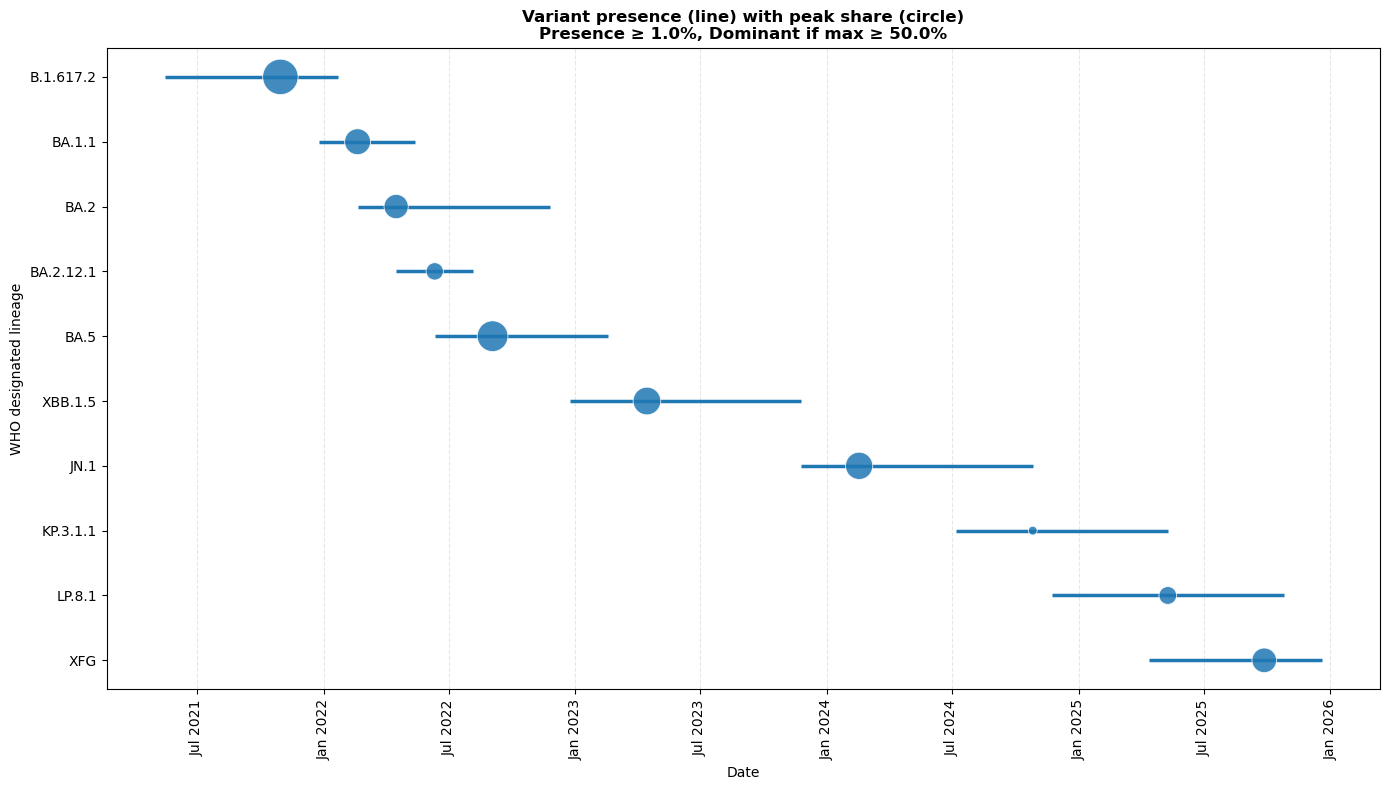

In [81]:
def plot_variant_timeline_peak_from_pivot(
    vp,                         # variant_plot or variant_plot_clean (index=datetime, columns=variants, values=%)
    presence_threshold=1.0,     # define "present" as share >= this (%)
    dominant_threshold=50.0,    # keep variants that ever exceed this (%); set None to keep all
    top_k=None,                 # if dominant_threshold filters too much, optionally keep top_k by max
    figsize=(14, 8),
    outpath="variant_timeline_peak.png",
):
    # --- input checks ---
    vp = vp.copy()
    vp.index = np.array(vp.index, dtype="datetime64[ns]")  # ensure datetime-like
    vp = vp.sort_index()

    # Ensure percent (you already do this, but keep it safe)
    if vp.to_numpy().max() <= 1.5:
        vp *= 100.0

    # Optionally drop "Other" from dominance logic (but still allow plotting if you want)
    # vp = vp.drop(columns=["Other"], errors="ignore")

    # --- choose variants to plot ---
    cols = vp.columns

    if dominant_threshold is not None:
        cols = cols[vp.max(axis=0) >= float(dominant_threshold)]

    if (len(cols) == 0) and (top_k is not None):
        cols = vp.max(axis=0).sort_values(ascending=False).head(int(top_k)).index

    vp = vp[cols]

    # --- compute start / peak / end based on presence threshold ---
    rows = []
    for v in vp.columns:
        s = vp[v]
        present = s[s >= float(presence_threshold)]
        if present.empty:
            continue

        start = present.index.min()
        end = present.index.max()
        peak_share = float(s.max())
        peak_date = s.idxmax()

        rows.append((v, start, peak_date, peak_share, end))

    if not rows:
        raise ValueError("No variants met the criteria. Lower presence_threshold or dominant_threshold.")

    # --- ordering (top to bottom) ---
    # Earlier peaks first; ties broken by higher peak
    rows = sorted(rows, key=lambda x: (x[2], -x[3]))
    variants = [r[0] for r in rows]

    # y positions (top at 0 visually)
    y = np.arange(len(variants))[::-1]

    starts = [r[1] for r in rows]
    peaks = [r[2] for r in rows]
    peak_vals = np.array([r[3] for r in rows], dtype=float)
    ends = [r[4] for r in rows]

    # marker sizes scaled by peak share
    pmin, pmax = float(peak_vals.min()), float(peak_vals.max())
    if pmax == pmin:
        sizes = np.full_like(peak_vals, 200.0)
    else:
        sizes = 40.0 + (peak_vals - pmin) * (650.0 - 40.0) / (pmax - pmin)

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    for yi, x0, x1 in zip(y, starts, ends):
        ax.hlines(yi, x0, x1, linewidth=2.5)

    ax.scatter(peaks, y, s=sizes, alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(variants)
    ax.set_ylabel("WHO designated lineage")
    ax.set_xlabel("Date")
    ax.set_title(
        f"Variant presence (line) with peak share (circle)\n"
        f"Presence ≥ {presence_threshold:.1f}%"
        + (f", Dominant if max ≥ {dominant_threshold:.1f}%" if dominant_threshold is not None else ""),
        fontweight="bold",
    )

    ax.grid(True, axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=90, ha="center")

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()


# --- Use EITHER pivot ---
# If you want only major + Other:
plot_variant_timeline_peak_from_pivot(
    variant_plot_clean,
    presence_threshold=1.0,     # appears if >= 1%
    dominant_threshold=50.0,    # keep variants that ever exceed 50%
    top_k=12,                   # fallback if none exceed 50%
    outpath="variant_timeline_peak_major.png",
)

# Or if you want all variants (may be cluttered):
# plot_variant_timeline_peak_from_pivot(
#     variant_plot,
#     presence_threshold=0.5,
#     dominant_threshold=50.0,
#     top_k=20,
#     outpath="variant_timeline_peak_all.png",
# )


In [114]:
def plot_variant_timeline_peak_from_pivot(
    vp,                          # variant_plot or variant_plot_clean (index=datetime, columns=variants, values=%)
    presence_threshold=1.0,      # define "present" as share >= this (%)
    dominant_threshold=50.0,     # keep variants that ever exceed this (%); set None to keep all
    top_k=None,                  # if dominant_threshold filters too much, optionally keep top_k by max
    variant_color_map=None,      # dict: {variant_name: color}. If None, auto-colors are used.
    cmap_name="tab20",           # colormap used when variant_color_map is None or incomplete
    figsize=(14, 8),
    outpath="variant_timeline_peak.png",
):
    # --- input checks ---
    vp = vp.copy()
    vp = vp.drop(columns=["Other"], errors="ignore")
    vp.index = np.array(vp.index, dtype="datetime64[ns]")
    vp = vp.sort_index()

    # ensure percent
    if vp.to_numpy().max() <= 1.5:
        vp *= 100.0

    # --- choose variants to plot ---
    cols = vp.columns
    max_share = vp.max(axis=0)

    if dominant_threshold is not None:
        if isinstance(dominant_threshold, (tuple, list)) and len(dominant_threshold) == 2:
            low, high = dominant_threshold
            cols = max_share[(max_share >= float(low)) & (max_share < float(high))].index
        else:
            cols = max_share[max_share >= float(dominant_threshold)].index

    # fallback
    if (len(cols) == 0) and (top_k is not None):
        cols = max_share.sort_values(ascending=False).head(int(top_k)).index

    vp = vp[cols]

    # --- compute start / peak / end ---
    rows = []
    for v in vp.columns:
        s = vp[v]
        present = s[s >= float(presence_threshold)]
        if present.empty:
            continue

        rows.append(
            {
                "variant": v,
                "start": present.index.min(),
                "peak_date": s.idxmax(),
                "peak_share": float(s.max()),
                "end": present.index.max(),
            }
        )

    if not rows:
        raise ValueError("No variants met the criteria.")

    # --- ordering (top to bottom): earlier peaks first, then bigger peaks ---
    rows = sorted(rows, key=lambda r: (r["peak_date"], -r["peak_share"]))
    variants = [r["variant"] for r in rows]
    y = np.arange(len(variants))[::-1]

    starts = [r["start"] for r in rows]
    peaks = [r["peak_date"] for r in rows]
    peak_vals = np.array([r["peak_share"] for r in rows], dtype=float)
    ends = [r["end"] for r in rows]

    # --- marker sizes ---
    pmin, pmax = float(peak_vals.min()), float(peak_vals.max())
    if pmax == pmin:
        sizes = np.full_like(peak_vals, 220.0)
    else:
        sizes = 60.0 + (peak_vals - pmin) * (700.0 - 60.0) / (pmax - pmin)

    # --- colors (robust) ---
    # If user provides a map, use it; otherwise auto-assign distinct colors
    colors = [None] * len(variants)

    # 1) fill from user map
    if variant_color_map is not None:
        for i, v in enumerate(variants):
            if v in variant_color_map:
                colors[i] = variant_color_map[v]

    # 2) auto-assign for any missing
    missing_idx = [i for i, c in enumerate(colors) if c is None]
    if missing_idx:
        cmap = plt.cm.get_cmap(cmap_name, len(missing_idx))
        for j, i in enumerate(missing_idx):
            colors[i] = cmap(j)

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    # Force colors explicitly (prevents style/rcParams from overriding)
    for yi, x0, x1, c in zip(y, starts, ends, colors):
        ax.hlines(
            y=yi,
            xmin=x0,
            xmax=x1,
            linewidth=3.0,
            colors=[c],     # <--- FORCE
            alpha=0.75,
        )

    ax.scatter(
        peaks,
        y,
        s=sizes,
        facecolors=colors,       # <--- FORCE
        edgecolors="white",
        linewidths=0.7,
        alpha=0.9,
        zorder=3,
    )

    for yi, x_peak, val, c in zip(y, peaks, peak_vals, colors):
        ax.annotate(
            f"{val:.1f}%",
            xy=(x_peak, yi),
            xytext=(6, 6),              # offset in points
            textcoords="offset points",
            fontsize=9,
            color=c,
            weight="bold",
            ha="left",
            va="bottom",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(variants)
    ax.set_ylabel("WHO designated lineage")
    ax.set_xlabel("Date")

    if isinstance(dominant_threshold, (tuple, list)) and len(dominant_threshold) == 2:
        low, high = dominant_threshold
        dominance_text = f"Peak proportion {low:.0f}–{high:.0f}%"
    elif dominant_threshold is not None:
        dominance_text = f"Peak proportion ≥ {float(dominant_threshold):.0f}%"
    else:
        dominance_text = "All variants"

    ax.set_title(
        "Variant presence (line) with peak share (circle)\n"
        + dominance_text,
        fontweight="bold",
    )

    ax.grid(True, axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=90, ha="center")

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

/var/folders/vy/m4l1bmcs7xd4nmd991yq7qkr0000gn/T/ipykernel_35302/3943410658.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, len(missing_idx))


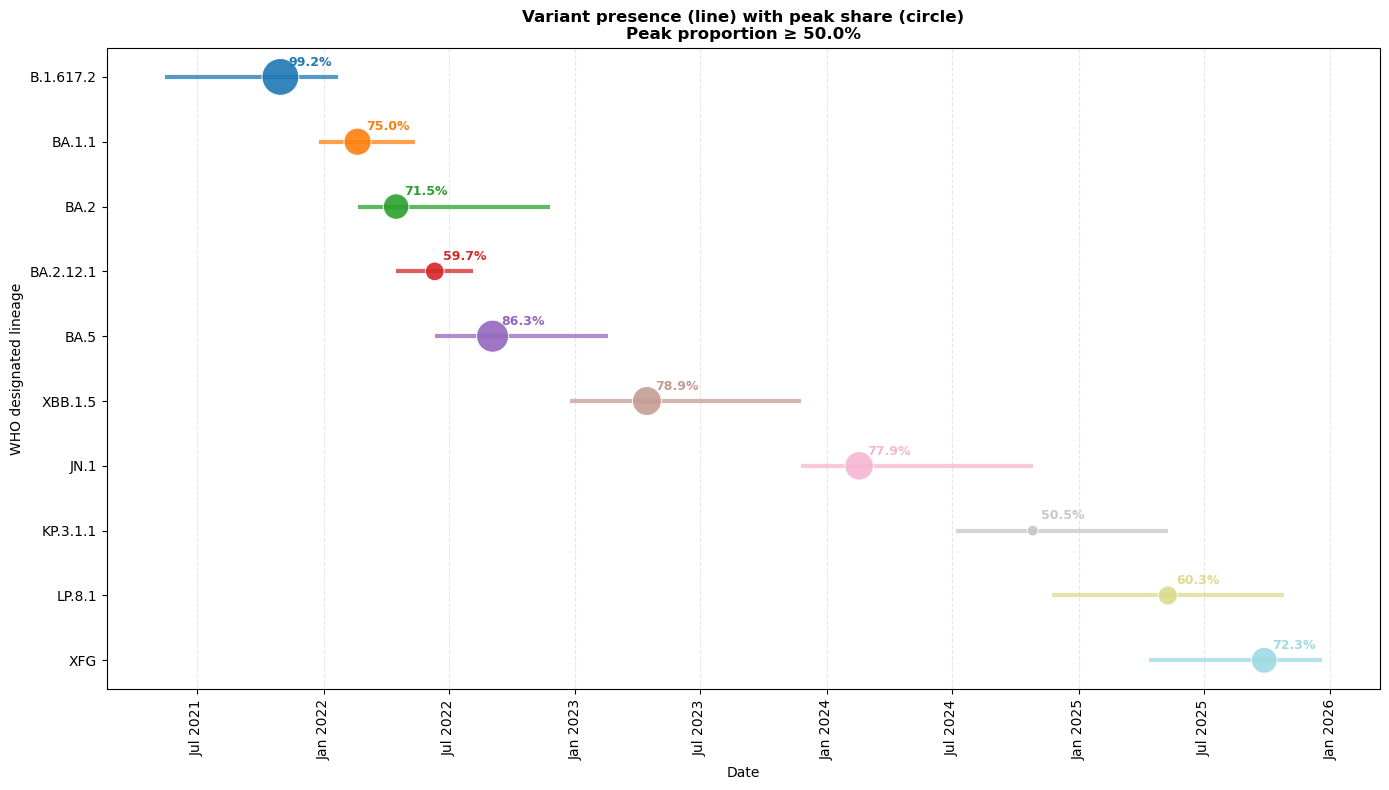

In [98]:
plot_variant_timeline_peak_from_pivot(
    variant_plot_clean,
    presence_threshold=1.0,     # appears if >= 1%
    dominant_threshold=50.0,    # keep variants that ever exceed 50%
    top_k=12,                   # fallback if none exceed 50%
    outpath="variant_50.png",
)

/var/folders/vy/m4l1bmcs7xd4nmd991yq7qkr0000gn/T/ipykernel_35302/2694968247.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, len(missing_idx))


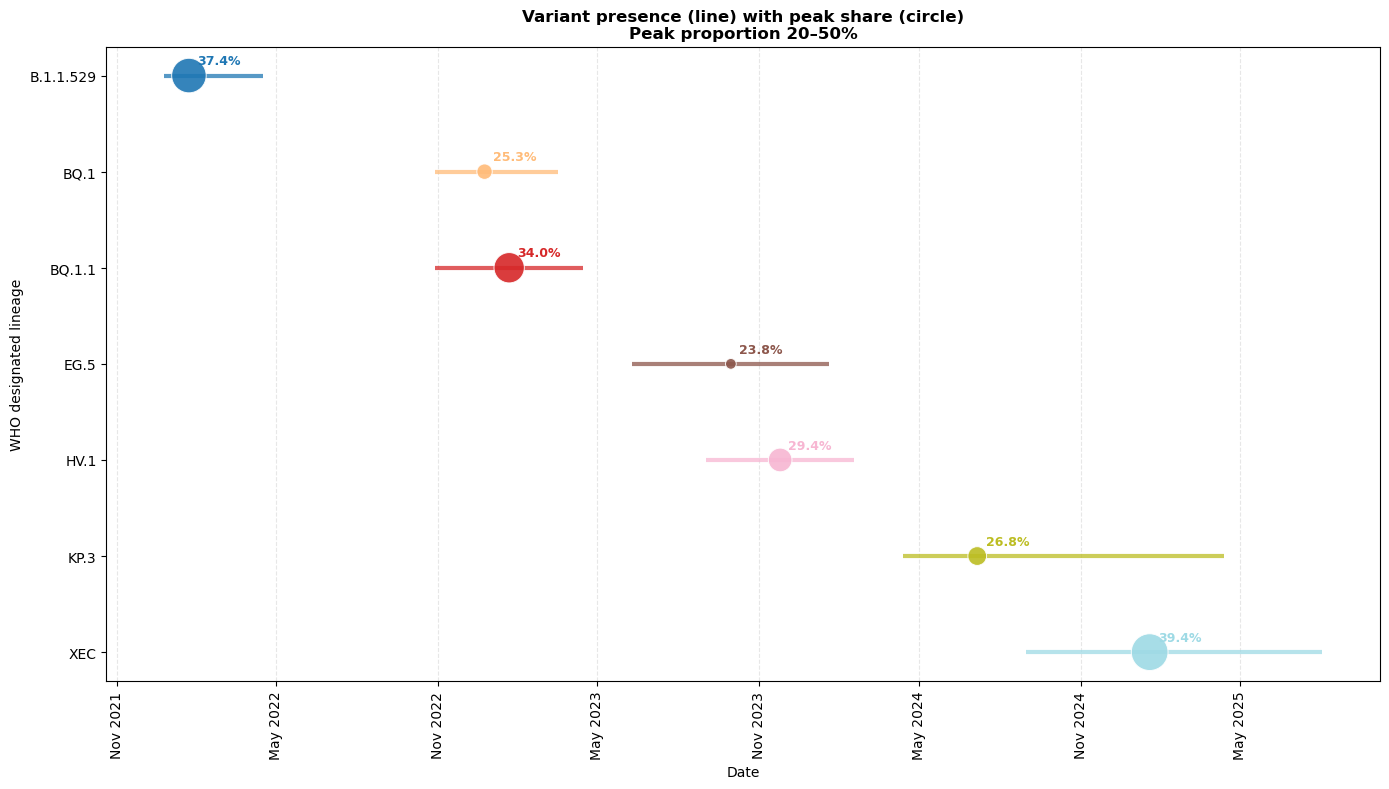

In [117]:
plot_variant_timeline_peak_from_pivot(
    variant_plot_clean,
    presence_threshold=1.0,     # appears if >= 1%
    dominant_threshold=(20,50),    # keep variants that ever exceed 50%
    top_k=12,                   # fallback if none exceed 50%
    outpath="variant_20.png",
)

the number of first appear variants over time

In [122]:
def plot_first_appearance_count(
    vp,                       # variant_plot or variant_plot_clean
    appearance_threshold=0.5, # % defining "appearance"
    cumulative=False,         # False = per period, True = cumulative
    freq="M",                 # resample frequency: "W", "M", "Q"
    label_every=1, 
    figsize=(12, 5),
    outpath="variant_first_appearance_count.png",
):
    vp = vp.copy().sort_index()

    # Remove 'Other' if present
    vp = vp.drop(columns=["Other"], errors="ignore")

    # Ensure percent
    if vp.to_numpy().max() <= 1.5:
        vp *= 100.0

    # --- first appearance date per variant ---
    first_dates = {}
    for v in vp.columns:
        s = vp[v]
        appeared = s[s >= appearance_threshold]
        if not appeared.empty:
            first_dates[v] = appeared.index.min()

    first_df = (
        pd.Series(first_dates, name="first_date")
        .to_frame()
        .reset_index()
        .rename(columns={"index": "variant"})
    )
    total_variants = first_df.shape[0]

    # --- count appearances over time ---
    counts = (
        first_df
        .set_index("first_date")
        .resample(freq)
        .size()
        .sort_index()
    )

    if cumulative:
        counts = counts.cumsum()

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        counts.index,
        counts.values,
        marker="o",
        linewidth=2,
    )

    for i, (x, y) in enumerate(zip(counts.index, counts.values)):
        if i % label_every != 0:
            continue
        ax.annotate(
            str(int(y)),
            xy=(x, y),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
        )

    y_max = counts.max()
    ax.set_ylim(0-0.2, y_max * 1.15 if y_max > 0 else 1)

    ax.text(
        0.02, 0.95,
        f"Total variants: {total_variants}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
    )

    ax.set_title(
        "Number of newly appearing variants over time"
        + (" (cumulative)" if cumulative else ""),
        fontweight="bold",
        fontsize=14,
    )
    ax.set_ylabel("Number of variants")
    ax.set_xlabel("Date")

    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    return first_df, counts

/var/folders/vy/m4l1bmcs7xd4nmd991yq7qkr0000gn/T/ipykernel_35302/2779362572.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample(freq)


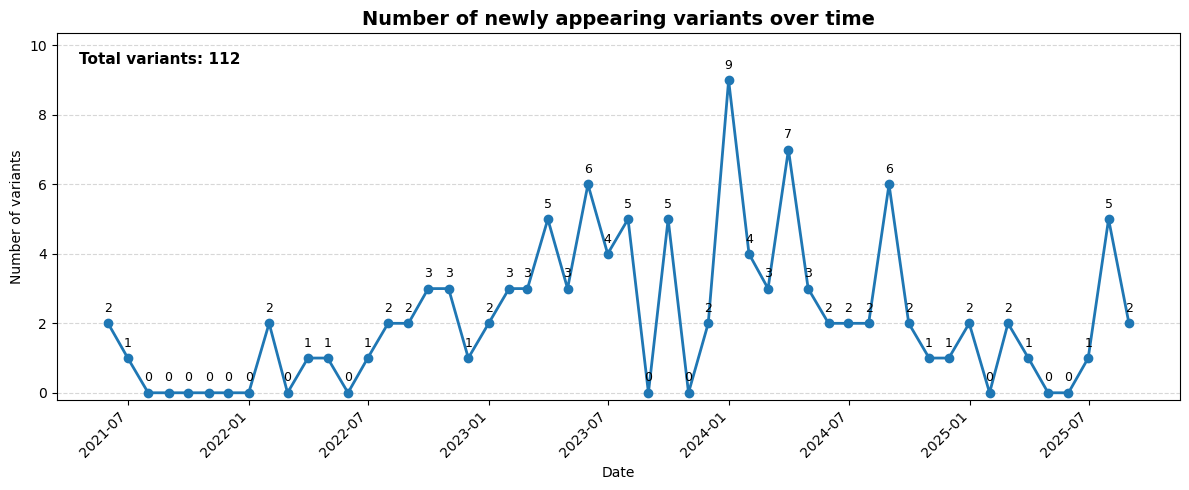

In [126]:
first_df, counts = plot_first_appearance_count(
    vp=variant_plot,
    appearance_threshold=0.01,
    cumulative=False,
    freq="M",
)

In [127]:
def build_variant_timeline_csv(
    vp,                               # use variant_plot (all variants) or variant_pivot
    presence_threshold=0.5,           # % threshold to define "present" (e.g., 0.5 or 1.0)
    include_other=False,              # set True if you really want "Other" included
    outpath="variant_timeline_all.csv"
):
    """
    Produces a CSV with start_date, peak_date, end_date, duration_days for EACH variant.
    start/end are based on share >= presence_threshold.
    peak is the global max share date (within the available series).
    """

    df = vp.copy()

    # ensure datetime index
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df.loc[df.index.notna()].sort_index()

    # optionally remove "Other"
    if not include_other:
        df = df.drop(columns=["Other"], errors="ignore")

    # ensure percent
    maxv = float(np.nanmax(df.to_numpy())) if df.size else 0.0
    if maxv <= 1.5:
        df = df * 100.0

    rows = []
    for v in df.columns:
        s = df[v].astype(float)

        # presence window
        present = s[s >= float(presence_threshold)]
        if present.empty:
            # variant never appears above threshold
            rows.append(
                {
                    "variant": v,
                    "start_date": pd.NaT,
                    "peak_date": pd.NaT,
                    "end_date": pd.NaT,
                    "duration_days": np.nan,
                    "peak_share_pct": float(s.max()) if s.notna().any() else np.nan,
                }
            )
            continue

        start_date = present.index.min()
        end_date = present.index.max()

        # peak (global max)
        peak_share = float(s.max())
        peak_date = s.idxmax() if s.notna().any() else pd.NaT

        duration_days = int((end_date - start_date).days)

        rows.append(
            {
                "variant": v,
                "start_date": pd.to_datetime(start_date),
                "peak_date": pd.to_datetime(peak_date),
                "end_date": pd.to_datetime(end_date),
                "duration_days": duration_days,
                "peak_share_pct": peak_share,
            }
        )

    out = pd.DataFrame(rows).sort_values(
        ["start_date", "peak_date", "peak_share_pct"],
        ascending=[True, True, False],
        na_position="last",
    )

    out.to_csv(outpath, index=False)
    return out


# ===== Example usage =====
# Use variant_plot (recommended: all variants, already in %)
timeline_df = build_variant_timeline_csv(
    vp=variant_plot,                 # or variant_plot_clean / variant_pivot
    presence_threshold=0.01,          # tune: 0.5 or 1.0
    include_other=False,
    outpath="variant_timeline_all.csv"
)

# Optional: inspect
print(timeline_df.head(20))

       variant start_date  peak_date   end_date  duration_days  peak_share_pct
0    B.1.617.2 2021-05-15 2021-10-30 2022-10-29            532       99.163841
7       BA.1.1 2021-05-15 2022-02-19 2024-07-06           1148       75.003941
16   B.1.1.529 2021-06-12 2022-01-22 2025-12-20           1652       37.381031
9         BA.2 2022-01-22 2022-04-16 2025-08-02           1288       71.547492
10   BA.2.12.1 2022-01-22 2022-06-11 2024-06-08            868       59.732178
1         BA.5 2022-03-19 2022-09-03 2024-03-16            728       86.272152
28        BA.4 2022-04-16 2022-07-09 2023-01-21            280       12.165232
29      BA.4.6 2022-06-11 2022-10-01 2024-12-21            924        9.735372
94     BA.2.75 2022-07-09 2022-10-29 2023-06-10            336        1.134985
91    BA.5.2.6 2022-07-09 2022-11-26 2024-03-16            616        1.613415
37        BF.7 2022-08-06 2022-11-26 2024-10-26            812        7.058620
98       BF.11 2022-08-06 2022-11-26 2023-06-10     

In [63]:
def build_variant_share_and_marker_wide(variant2: pd.DataFrame) -> pd.DataFrame:
    """
    Marker rule (UPDATED):
      - For each variant, find its FIRST date of appearance (first non-NA share).
      - If the variant is dominant (highest share) on ANY date in the series, mark 1 at its start date.
      - If it is NEVER dominant, mark 2 at its start date.
      - For dates AFTER start:
          * 0 if variant is present (share notna)
          * NaN if absent
    """
    df = variant2.copy()

    # 1) exclude Other
    df = df.loc[df["variant"].ne("Other")].copy()

    # 2) ensure datetime Date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.loc[df["Date"].notna()].copy()

    # wide shares (one row per Date)
    shares = (
        df.pivot_table(index="Date", columns="variant", values="share", aggfunc="mean")
          .sort_index()
    )

    # dominant variant each date (ignores NaNs)
    dominant = shares.idxmax(axis=1)

    # variants that are ever dominant at any date
    ever_dominant = set(dominant.dropna().unique())

    # build marker matrix
    markers = pd.DataFrame(np.nan, index=shares.index, columns=shares.columns)

    for v in shares.columns:
        s = shares[v]
        start_date = s.first_valid_index()
        if start_date is None:
            continue

        # start marker: 1 if ever dominant, else 2
        markers.loc[start_date, v] = 1 if v in ever_dominant else 2

        # after start: 0 when present, NaN when absent
        mask_after = (shares.index > start_date) & s.notna()
        markers.loc[mask_after, v] = 0

    # rename + combine
    shares = shares.add_suffix("_share")
    markers = markers.add_suffix("_marker")

    out = pd.concat([shares, markers], axis=1)

    # optional: order columns (variant_share then variant_marker)
    variants = shares.columns.str.replace("_share$", "", regex=True)
    ordered_cols = []
    for v in sorted(variants):
        ordered_cols.append(f"{v}_share")
        ordered_cols.append(f"{v}_marker")
    out = out.reindex(columns=ordered_cols).reset_index()

    return out


# ===== usage =====
wide_df = build_variant_share_and_marker_wide(variant2)

print(wide_df.head())

variant       Date  A.2.5_share  A.2.5_marker  AY.1_share  AY.1_marker  \
0       2021-01-30     0.001548           2.0         NaN          NaN   
1       2021-02-13     0.000673           0.0         NaN          NaN   
2       2021-02-27     0.001428           0.0         NaN          NaN   
3       2021-03-06     0.001688           0.0         NaN          NaN   
4       2021-03-13     0.001194           0.0         NaN          NaN   

variant  AY.2_share  AY.2_marker  AY.3_share  AY.3_marker  B.1_share  ...  \
0               NaN          NaN         NaN          NaN   0.044735  ...   
1               NaN          NaN         NaN          NaN   0.037725  ...   
2               NaN          NaN         NaN          NaN   0.033793  ...   
3               NaN          NaN         NaN          NaN        NaN  ...   
4               NaN          NaN         NaN          NaN        NaN  ...   

variant  XFG.1.1_share  XFG.1.1_marker  XFG.14.1_share  XFG.14.1_marker  \
0                

In [64]:
wide_df.to_csv('variant_all_marker.csv', index=False)